# Analysis of MNase-seq replication timing

March 25, 2024

This notebook aims to examine the raw MNase-seq data and compare to the Brewer replication timing.



In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from cc_src.mnase_replication_timing_analysis import MNaseOriginAnalysis

In [3]:
mnase_analysis = MNaseOriginAnalysis()

In [4]:
replicate = 2
chromosome = 16
mnase_analysis.load_mnase_data(replicate, chromosome)

In [5]:
mnase_analysis.compute_sliding_window_counts_all_times()
mnase_analysis.normalize_samples()

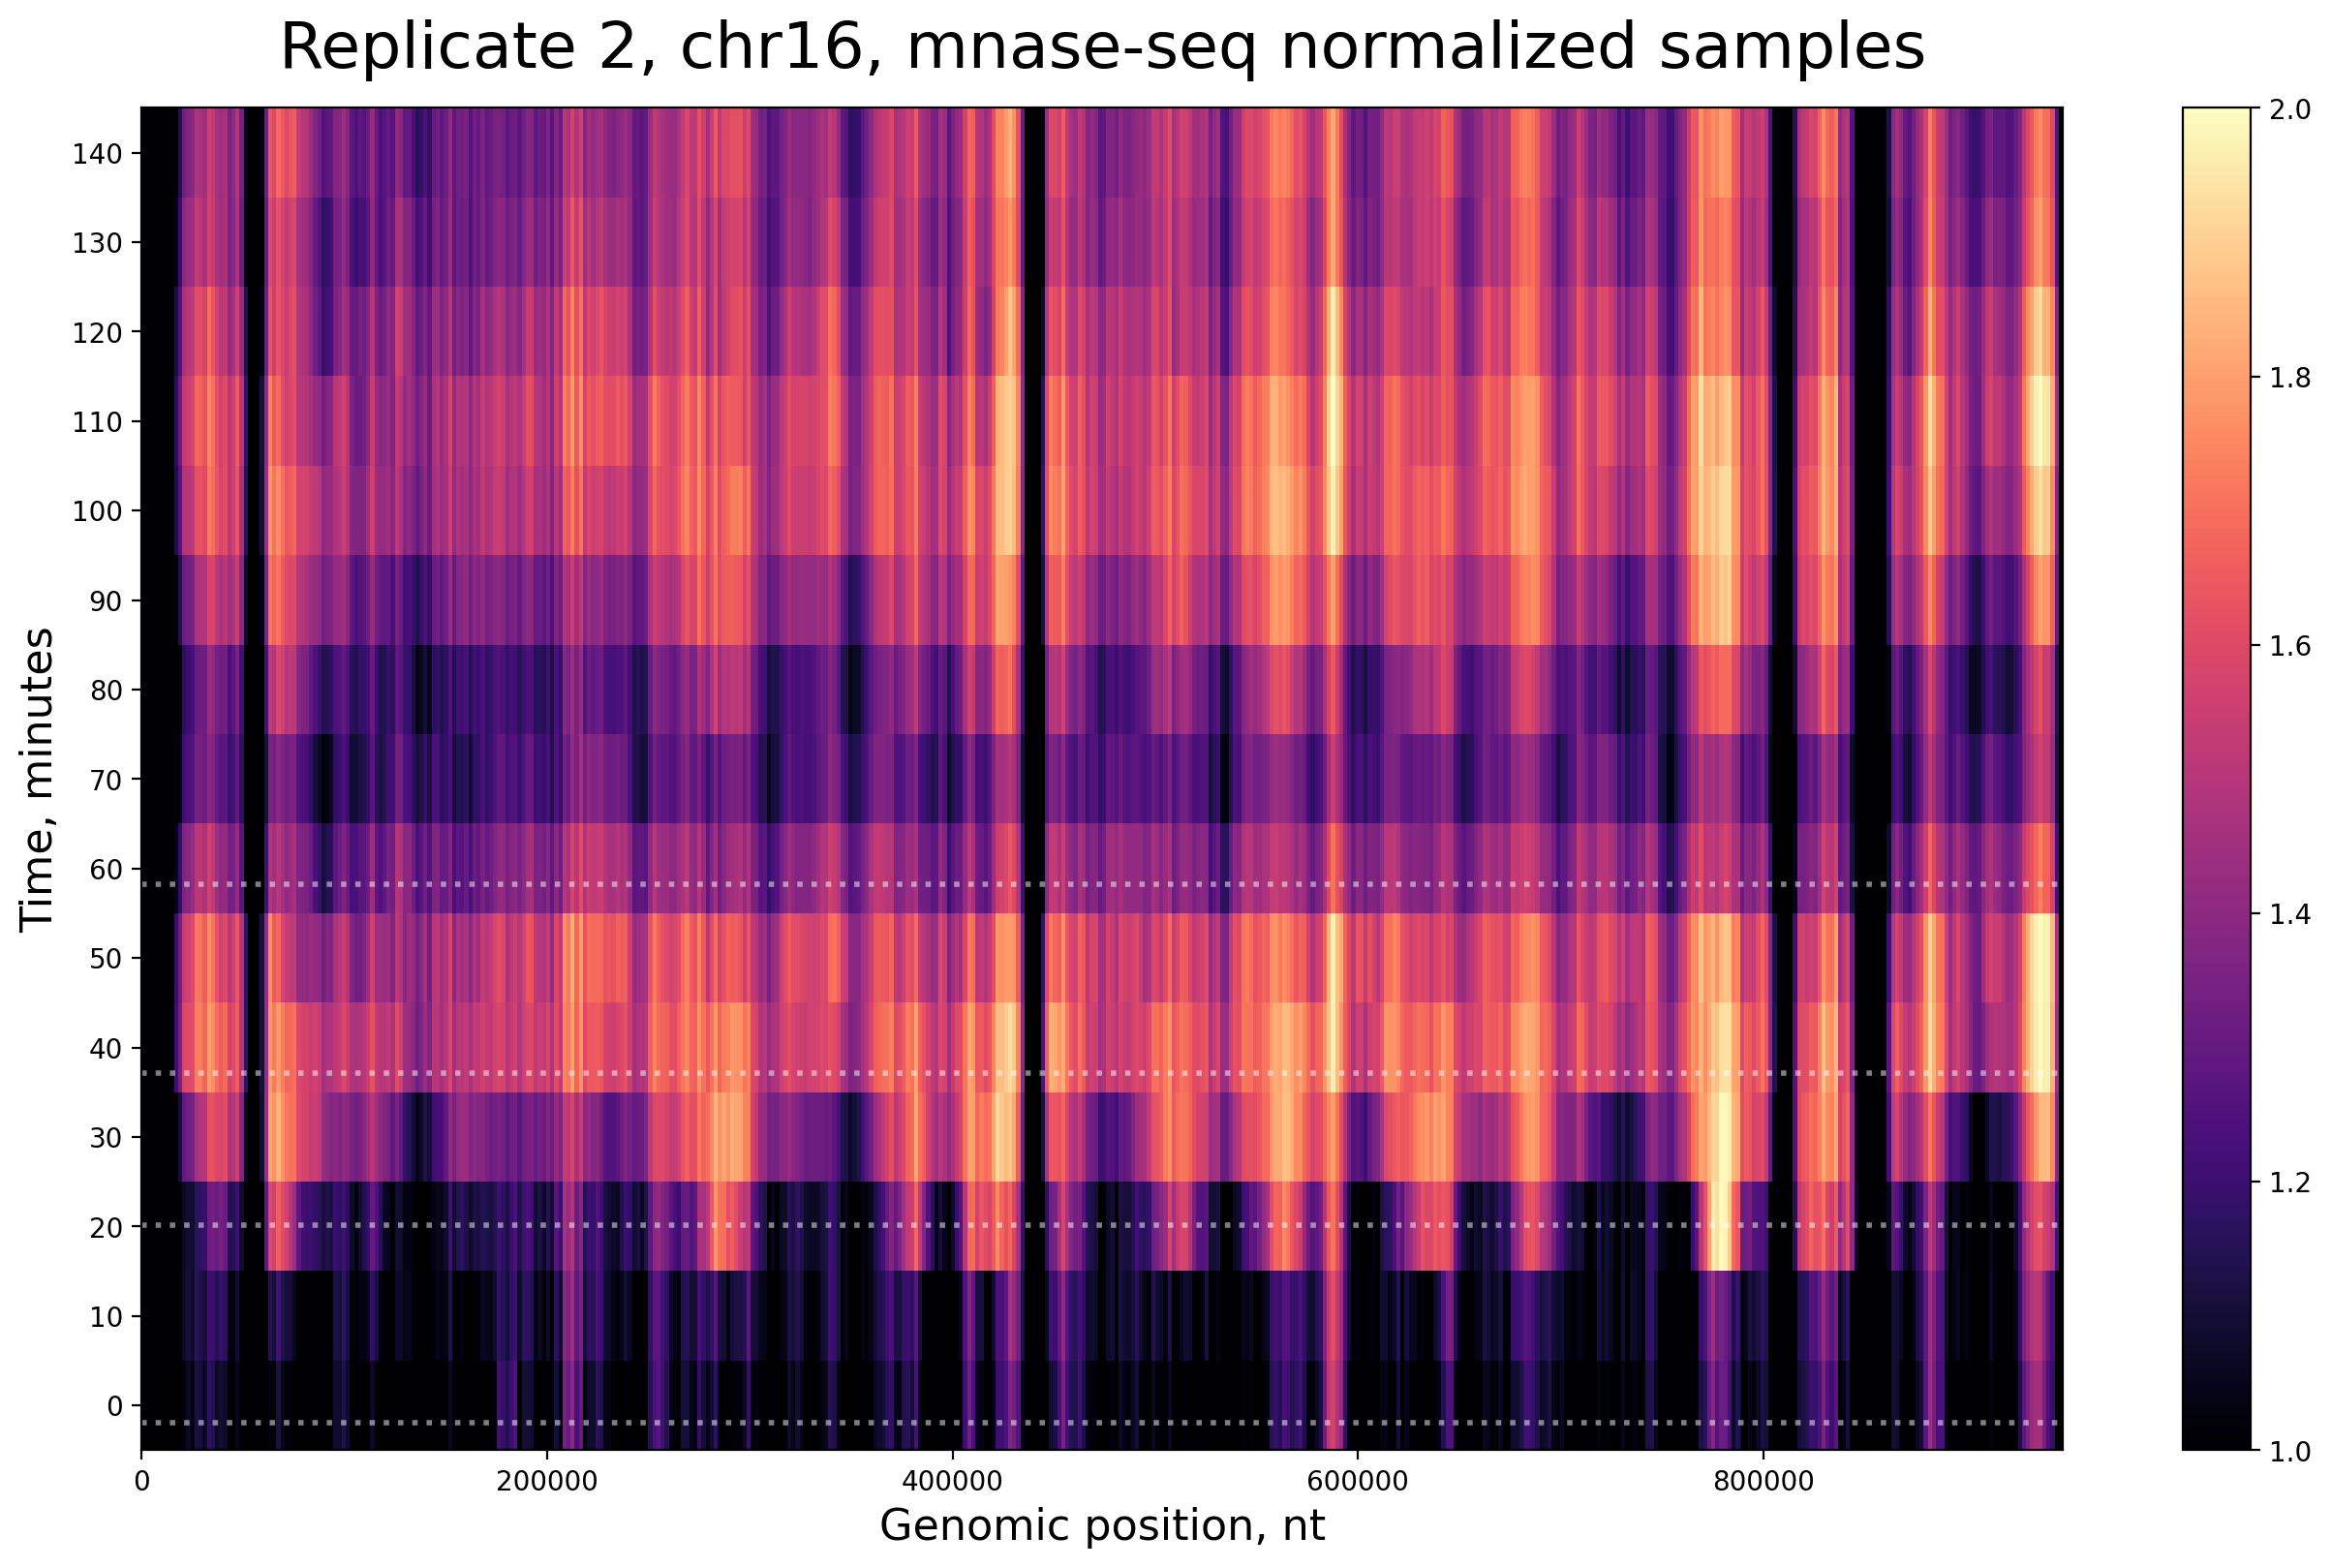

In [6]:
mnase_analysis.plot_heatmap()

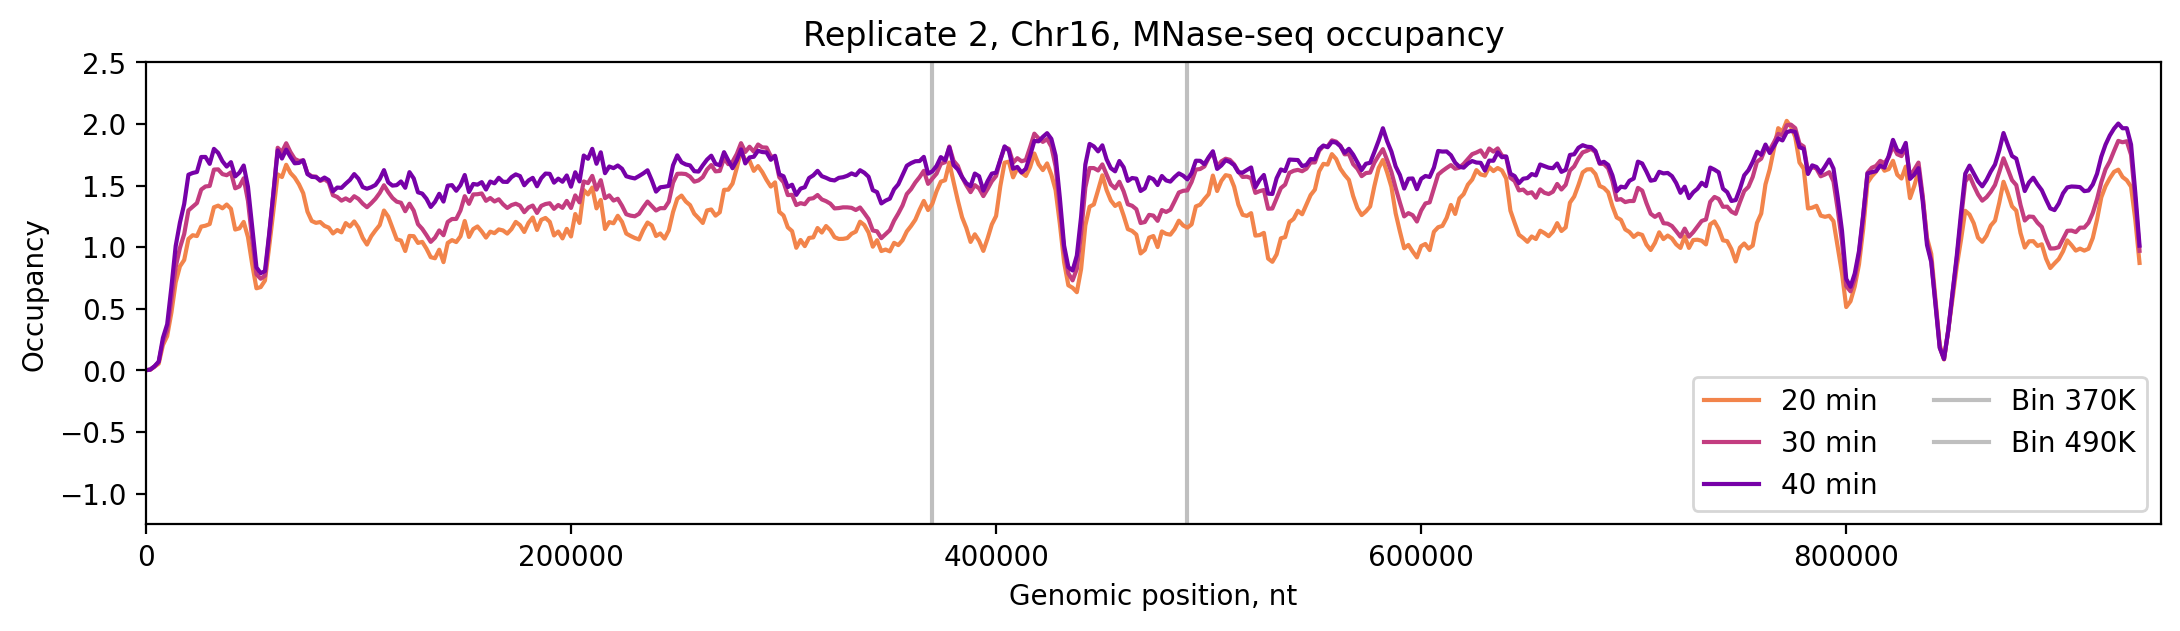

In [7]:
selected_bins=[370000//mnase_analysis.step, 490000//mnase_analysis.step]
time_indices=[2, 3, 4]
mnase_analysis.plot_bin_occupancy_for_selected_timepoints(time_indices, selected_bins)

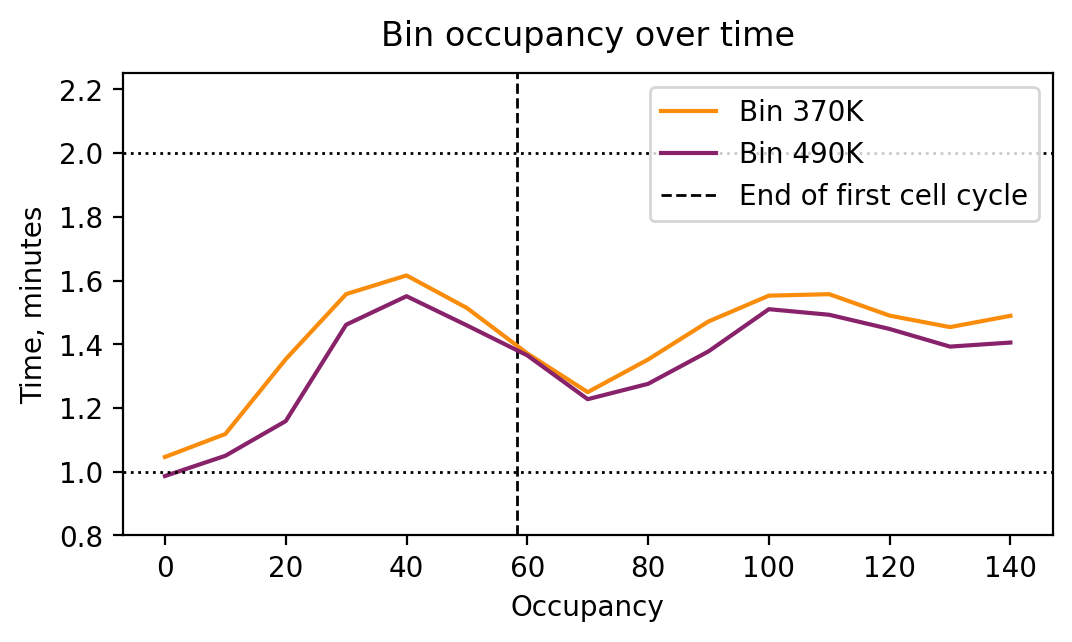

In [8]:
mnase_analysis.plot_selected_bin_occupancy(selected_bins)

In [9]:
replicate = 1
chromosome = 10
mnase_analysis.load_mnase_data(replicate, chromosome)

In [10]:
mnase_analysis.compute_sliding_window_counts_all_times(window_size=10000, step=2500)
mnase_analysis.normalize_samples()

In [ ]:
mnase_analysis.plot_heatmap()

In [ ]:
dat = mnase_analysis.counts_normalized_by_copy.copy()


q_lo = np.quantile(dat, 0.05, axis=0)
q_hi = np.quantile(dat, 0.95, axis=0)

hi_lo_avg_range = q_hi.mean() - q_lo.mean() + 0.001
#dat = (dat - q_lo) / (q_hi - q_lo)*hi_lo_avg_range + 1. # copy number range of values

plt.figure(figsize=(13, 6))
plt.imshow(dat, aspect='auto', origin='lower', cmap='magma',
           interpolation='none',
          extent=[0, mnase_analysis.chrom_len,
                 0, mnase_analysis.timepoints[-1]], vmin=1, vmax=2.)
plt.colorbar()
plt.show()

plt.figure(figsize=(13, 6))
plt.imshow(dat > 1.45, aspect='auto', origin='lower', cmap='magma',
           interpolation='none',
          extent=[0, mnase_analysis.chrom_len,
                 0, mnase_analysis.timepoints[-1]])
plt.colorbar()
